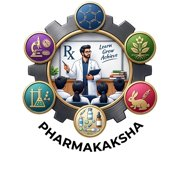

# BP301T · Unit III — Classification Models in Clinical Applications
**Pharmakaksha · Learn · Grow · Achieve**
*Introduction to Machine Learning in Pharmaceutical Sciences · B.Pharm Semester III · PCI NEP 2020*

This notebook contains every example and demo from the Unit III study notes, slides and video, in the same order.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ajreddys/learn-pharmakaksha-site/blob/main/content/BP301T%20Introduction%20to%20Machine%20Learning%20in%20Pharmaceutical%20Sciences%20%28Theory%29/BP301T_Unit3_Classification_Models.ipynb)

**How to use this notebook**
1. Open it at [learn.pharmakaksha.com](https://learn.pharmakaksha.com/notebooks/index.html?path=BP301T%20Introduction%20to%20Machine%20Learning%20in%20Pharmaceutical%20Sciences%20%28Theory%29/BP301T_Unit3_Classification_Models.ipynb) (no login needed) or in **Google Colab** with the button above (sign in with Google; use **File → Save a copy in Drive** to keep your work).
2. Click a code cell and press **Shift + Enter** to run it. Run the cells from top to bottom.
3. The practice datasets sit next to this notebook. In Colab they are read from GitHub automatically.

**Using learn.pharmakaksha.com**
Python runs inside your web browser, so nothing is installed and nothing is sent to a server. Use an up-to-date Chrome, Edge, Firefox or Safari, on a laptop or a phone.
- **The first run is slow.** The first time you run a cell, the browser downloads Python, which can take 10–30 seconds. The first `import sklearn` takes a few seconds more. After that, cells run quickly.
- **Check the kernel.** *Python (Pyodide)* appears at the top right. A filled circle means Python is busy, and an empty circle means it is ready.
- **If a cell hangs** or you want a fresh start, use **Kernel → Restart Kernel**, then run the cells from the top again.
- **Save your work.** Press **Ctrl + S** (**Cmd + S** on a Mac). Your work is saved in this browser only. It will not appear on another device, and clearing your browsing data or using a private/incognito window erases it. Use **File → Download** to keep a copy.
- **Start over.** The site keeps opening your saved copy of the notebook. To get the original version back, go to the file list, tick the notebook, click **Delete** and reload the page.

> All datasets are fictional teaching data (except scikit-learn's built-in breast-cancer dataset). The models are for learning machine learning only. They are not clinical tools.

## 3.1 Classification in clinical practice
**Classification** predicts a **category**: ADR yes/no, disease present/absent, responder/non-responder. We start with ADR prediction on `adr_patients.csv` (400 fictional patients).

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

URL = "https://raw.githubusercontent.com/ajreddys/learn-pharmakaksha-site/main/content/BP301T%20Introduction%20to%20Machine%20Learning%20in%20Pharmaceutical%20Sciences%20%28Theory%29/"

def load(name):
    """Read a practice CSV from this folder, or from GitHub (Colab)."""
    if os.path.exists(name):
        return pd.read_csv(name)
    return pd.read_csv(URL + name)

adr = load("adr_patients.csv")
adr["female"] = (adr["sex"] == "F").astype(int)
features = ["age", "female", "weight_kg", "crcl_ml_min", "num_drugs", "liver_disease", "prior_adr"]
X, y = adr[features], adr["adr"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
print("ADR rate:", y.mean())

## 3.2 Logistic regression
Logistic regression passes a linear score *z* through the **sigmoid** curve, p = 1 / (1 + e⁻ᶻ), so the output is always a probability between 0 and 1.

In [ ]:
z = np.linspace(-6, 6, 200)
plt.figure(figsize=(8, 4.5))
plt.plot(z, 1 / (1 + np.exp(-z)), color="#12303A", linewidth=2.5)
plt.axhline(0.5, color="#E07A2E", linestyle="--", label="Threshold 0.5")
plt.xlabel("Linear score z = b₀ + b₁x₁ + b₂x₂ + …")
plt.ylabel("Probability of ADR")
plt.title("The sigmoid turns any score into a probability")
plt.legend(); plt.grid(alpha=0.3); plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

coef = pd.DataFrame({"coefficient": logreg.coef_[0].round(3),
                     "odds_ratio": np.exp(logreg.coef_[0]).round(2)}, index=features)
print(coef)

An **odds ratio** above 1 raises the risk. Each extra drug multiplies the odds of an ADR by the `num_drugs` odds ratio; a previous ADR multiplies it by the `prior_adr` odds ratio.

## 3.3 Probability output and threshold

In [ ]:
proba = logreg.predict_proba(X_test)[:, 1]      # column 1 = probability of ADR
print("First five probabilities:", proba[:5].round(2))
print("Predictions at 0.5:      ", (proba[:5] >= 0.5).astype(int))
print("Predictions at 0.3:      ", (proba[:5] >= 0.3).astype(int))

## 3.4 The confusion matrix

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

pred = logreg.predict(X_test)                    # threshold 0.5
cm = confusion_matrix(y_test, pred)
print(cm)
tn, fp, fn, tp = cm.ravel()
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")

ConfusionMatrixDisplay(cm, display_labels=["No ADR", "ADR"]).plot(cmap="Greens", colorbar=False)
plt.title("Logistic regression, threshold 0.5"); plt.show()

## 3.5 Accuracy, sensitivity, specificity, precision and recall

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def report(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return pd.Series({"accuracy": (tp + tn) / (tp + tn + fp + fn),
                      "sensitivity (recall)": tp / (tp + fn),
                      "specificity": tn / (tn + fp),
                      "precision": tp / (tp + fp),
                      "F1": f1_score(y_true, y_pred)}).round(3)

print(report(y_test, pred))
print("\nsklearn check:", round(accuracy_score(y_test, pred), 3), round(recall_score(y_test, pred), 3),
      round(precision_score(y_test, pred), 3))

For **screening**, missing an ADR (a false negative) is costly, so we lower the threshold to raise sensitivity:

In [ ]:
pred_03 = (proba >= 0.3).astype(int)
print(pd.DataFrame({"threshold 0.5": report(y_test, pred), "threshold 0.3": report(y_test, pred_03)}))

## 3.6 ROC curve and AUC
The ROC curve plots sensitivity against 1 − specificity for **every** threshold. AUC (area under the curve) summarises it: 0.5 = coin toss, 1.0 = perfect.

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thr = roc_curve(y_test, proba)
auc = roc_auc_score(y_test, proba)
print("AUC =", round(auc, 3))

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color="#E07A2E", linewidth=2.5, label=f"Logistic regression (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], color="grey", linestyle="--", label="Chance (AUC = 0.50)")
plt.xlabel("False positive rate (1 − specificity)")
plt.ylabel("True positive rate (sensitivity)")
plt.title("ROC curve: ADR prediction")
plt.legend(loc="lower right"); plt.grid(alpha=0.3); plt.show()

## 3.7 k-nearest neighbours (k-NN): disease risk
k-NN classifies a new patient by a **vote of the k most similar patients**. Distances need features on the same scale, so we put `StandardScaler` and the model in one **pipeline**. Here we use scikit-learn's built-in Wisconsin breast-cancer dataset: 569 real tumour samples, 30 features, malignant or benign.

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

bc = load_breast_cancer()
Xb = pd.DataFrame(bc.data, columns=bc.feature_names)
yb = pd.Series(bc.target).map({0: 1, 1: 0})          # make 1 = malignant (the "positive" class)
print(Xb.shape, " malignant:", yb.sum(), " benign:", (yb == 0).sum())

Xb_train, Xb_test, yb_train, yb_test = train_test_split(Xb, yb, test_size=0.25, random_state=42, stratify=yb)

for k in [1, 3, 5, 7, 9, 15, 25]:
    knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k)).fit(Xb_train, yb_train)
    print(f"k = {k:>2}: test accuracy = {knn.score(Xb_test, yb_test):.3f}")

In [ ]:
knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=7)).fit(Xb_train, yb_train)
pb = knn.predict(Xb_test)
print(report(yb_test, pb))
print("AUC =", round(roc_auc_score(yb_test, knn.predict_proba(Xb_test)[:, 1]), 3))

unscaled = KNeighborsClassifier(n_neighbors=7).fit(Xb_train, yb_train)
print("Without scaling, accuracy =", round(unscaled.score(Xb_test, yb_test), 3))

## Worked example: predicting responders to diabetes therapy
`treatment_response.csv` holds 300 fictional type 2 diabetes patients. `responder` = 1 when HbA1c fell by at least 1% after six months. We compare logistic regression and k-NN.

In [ ]:
tr = load("treatment_response.csv")
Xt = tr[["age", "bmi", "baseline_hba1c", "adherence_pct", "diabetes_years"]]
yt = tr["responder"]
Xt_train, Xt_test, yt_train, yt_test = train_test_split(Xt, yt, test_size=0.25, random_state=42, stratify=yt)

models = {"Logistic regression": make_pipeline(StandardScaler(), LogisticRegression()),
          "k-NN (k = 15)": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=15))}
plt.figure(figsize=(6, 6))
for (name, m), colour in zip(models.items(), ["#E07A2E", "#17725C"]):
    m.fit(Xt_train, yt_train)
    p = m.predict_proba(Xt_test)[:, 1]
    f, t_, _ = roc_curve(yt_test, p)
    a = roc_auc_score(yt_test, p)
    print(f"{name}: accuracy = {m.score(Xt_test, yt_test):.3f}, AUC = {a:.3f}")
    plt.plot(f, t_, color=colour, linewidth=2.5, label=f"{name} (AUC = {a:.2f})")
plt.plot([0, 1], [0, 1], color="grey", linestyle="--")
plt.xlabel("False positive rate (1 − specificity)"); plt.ylabel("True positive rate (sensitivity)")
plt.title("Responder prediction: two classifiers")
plt.legend(loc="lower right"); plt.grid(alpha=0.3); plt.show()

In [ ]:
lr_t = models["Logistic regression"]
print("Odds ratio per 1 SD increase:")
print(pd.Series(np.exp(lr_t[-1].coef_[0]), index=Xt.columns).round(2))

## Quick check
A test has sensitivity 95% and specificity 60%. Is it better for ruling a disease **out** or **in**? Decide, then run the cell.

In [ ]:
print("Ruling OUT: high sensitivity means few false negatives, so a negative result is reassuring (SnNout).")

## Try it yourself (lab)
Write your code in the empty cells. Solutions are at the end of the notebook.

**1.** Use the ADR logistic model with a threshold of 0.2. Print the confusion matrix and the sensitivity.

**2.** Predict the ADR probability for a 78-year-old woman, 52 kg, CrCl 28 mL/min, 9 drugs, no liver disease, previous ADR.

**3.** Train k-NN on the breast-cancer data with k = 3 and k = 51. Which has the higher test accuracy?

**4.** For the responder data, which feature has the largest odds ratio? Is that clinically sensible?

---
## Solutions

In [ ]:
# 1
p02 = (proba >= 0.2).astype(int)
print(confusion_matrix(y_test, p02))
print("Sensitivity:", round(recall_score(y_test, p02), 3))

In [ ]:
# 2
new = pd.DataFrame([{"age": 78, "female": 1, "weight_kg": 52, "crcl_ml_min": 28,
                     "num_drugs": 9, "liver_disease": 0, "prior_adr": 1}])
print("ADR probability:", round(logreg.predict_proba(new)[0, 1], 2))

In [ ]:
# 3
for k in [3, 51]:
    m = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k)).fit(Xb_train, yb_train)
    print(k, round(m.score(Xb_test, yb_test), 3))

In [ ]:
# 4
print(pd.Series(np.exp(lr_t[-1].coef_[0]), index=Xt.columns).sort_values(ascending=False).round(2))
# Adherence: patients who take their medicine are more likely to respond.

---
**Next:** Unit IV — Tree-Based Models and Ensemble Learning. Pharmakaksha · Learn · Grow · Achieve